Для трейна модели я вручную разметила около 500 кадров с онлайн камеры 
https://www.youtube.com/watch?v=bYlEgU2tU5w

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.8/978.8 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [3]:
!pip install ffmpeg

  Preparing metadata (setup.py) ... done
  Created wheel for ffmpeg: filename=ffmpeg-1.4-py3-none-any.whl size=6083 sha256=338c84d237a9e8cf4c4906c835215895ebbe0fe3e54a75f6d0f86e459ee72f0a
  Stored in directory: /root/.cache/pip/wheels/56/30/c5/576bdd729f3bc062d62a551be7fefd6ed2f761901568171e4e
Successfully built ffmpeg


In [2]:
import zipfile
import os

zip_path = "/content/dataset.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [4]:
import os
import cv2
from ultralytics import YOLO
from pathlib import Path
import subprocess
import ffmpeg
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import shutil

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
images_path = "dataset/train/images"
labels_path = "dataset/train/labels"
val_images_path = "dataset/val/images"
val_labels_path = "dataset/val/labels"

os.makedirs(val_images_path, exist_ok=True)
os.makedirs(val_labels_path, exist_ok=True)

image_files = [f for f in os.listdir(images_path) if f.endswith(".jpg")]

val_files = random.sample(image_files, k=int(len(image_files) * 0.15))

for file_name in val_files:
    shutil.move(
        os.path.join(images_path, file_name), os.path.join(val_images_path, file_name)
    )

    label_file = file_name.replace(".jpg", ".txt")
    if os.path.exists(os.path.join(labels_path, label_file)):
        shutil.move(
            os.path.join(labels_path, label_file),
            os.path.join(val_labels_path, label_file),
        )

print(f"Перенесено {len(val_files)} изображений и меток в папку валидации.")

Перенесено 68 изображений и меток в папку валидации.


In [6]:
import yaml

dataset_path = Path("dataset")


data = {
    "path": "/content/dataset",
    "train": "train",
    "val": "val",
    "names": {"0": "dog"},
}

# Путь для сохранения файла
yaml_path = dataset_path / "data.yaml"

# Запись данных в YAML
with open(yaml_path, "w") as yaml_file:
    yaml.dump(data, yaml_file, default_flow_style=False)

print(f"Файл data.yaml успешно создан в {yaml_path}")

Файл data.yaml успешно создан в dataset/data.yaml


In [7]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device name: NVIDIA L4


In [9]:
from sys import path_importer_cache
model = YOLO("yolov8s.pt")

model.train(
    data="dataset/data.yaml",
    project="runs",
    epochs=100,
    patience=20,
    batch=16,
    imgsz=640,
    augment=True,
    device=0
)

Ultralytics 8.3.111 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=dataset/data.yaml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=runs, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, forma

train: Scanning /content/dataset/train/labels.cache... 389 images, 0 backgrounds, 0 corrupt: 100%|██████████| 389/389 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 763.0±675.0 MB/s, size: 76.8 KB)


val: Scanning /content/dataset/val/labels.cache... 68 images, 0 backgrounds, 0 corrupt: 100%|██████████| 68/68 [00:00<?, ?it/s]


...

                   all         68        338      0.922      0.962      0.964      0.754


EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 66, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

86 epochs completed in 0.111 hours.
Optimizer stripped from runs/train2/weights/last.pt, 22.5MB
Optimizer stripped from runs/train2/weights/best.pt, 22.5MB

Validating runs/train2/weights/best.pt...
Ultralytics 8.3.111 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.57it/s]


                   all         68        338      0.911      0.941      0.966      0.752
Speed: 0.1ms preprocess, 10.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ed5a4056690>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [11]:
model = YOLO(
    "/content/runs/train2/weights/best.pt"
)
model.val()

Ultralytics 8.3.111 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2105.6±512.1 MB/s, size: 67.7 KB)


val: Scanning /content/dataset/val/labels.cache... 68 images, 0 backgrounds, 0 corrupt: 100%|██████████| 68/68 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  3.45it/s]


                   all         68        338      0.908      0.973       0.97      0.762
Speed: 1.5ms preprocess, 4.4ms inference, 0.0ms loss, 6.6ms postprocess per image
Results saved to runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ed59c209e90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

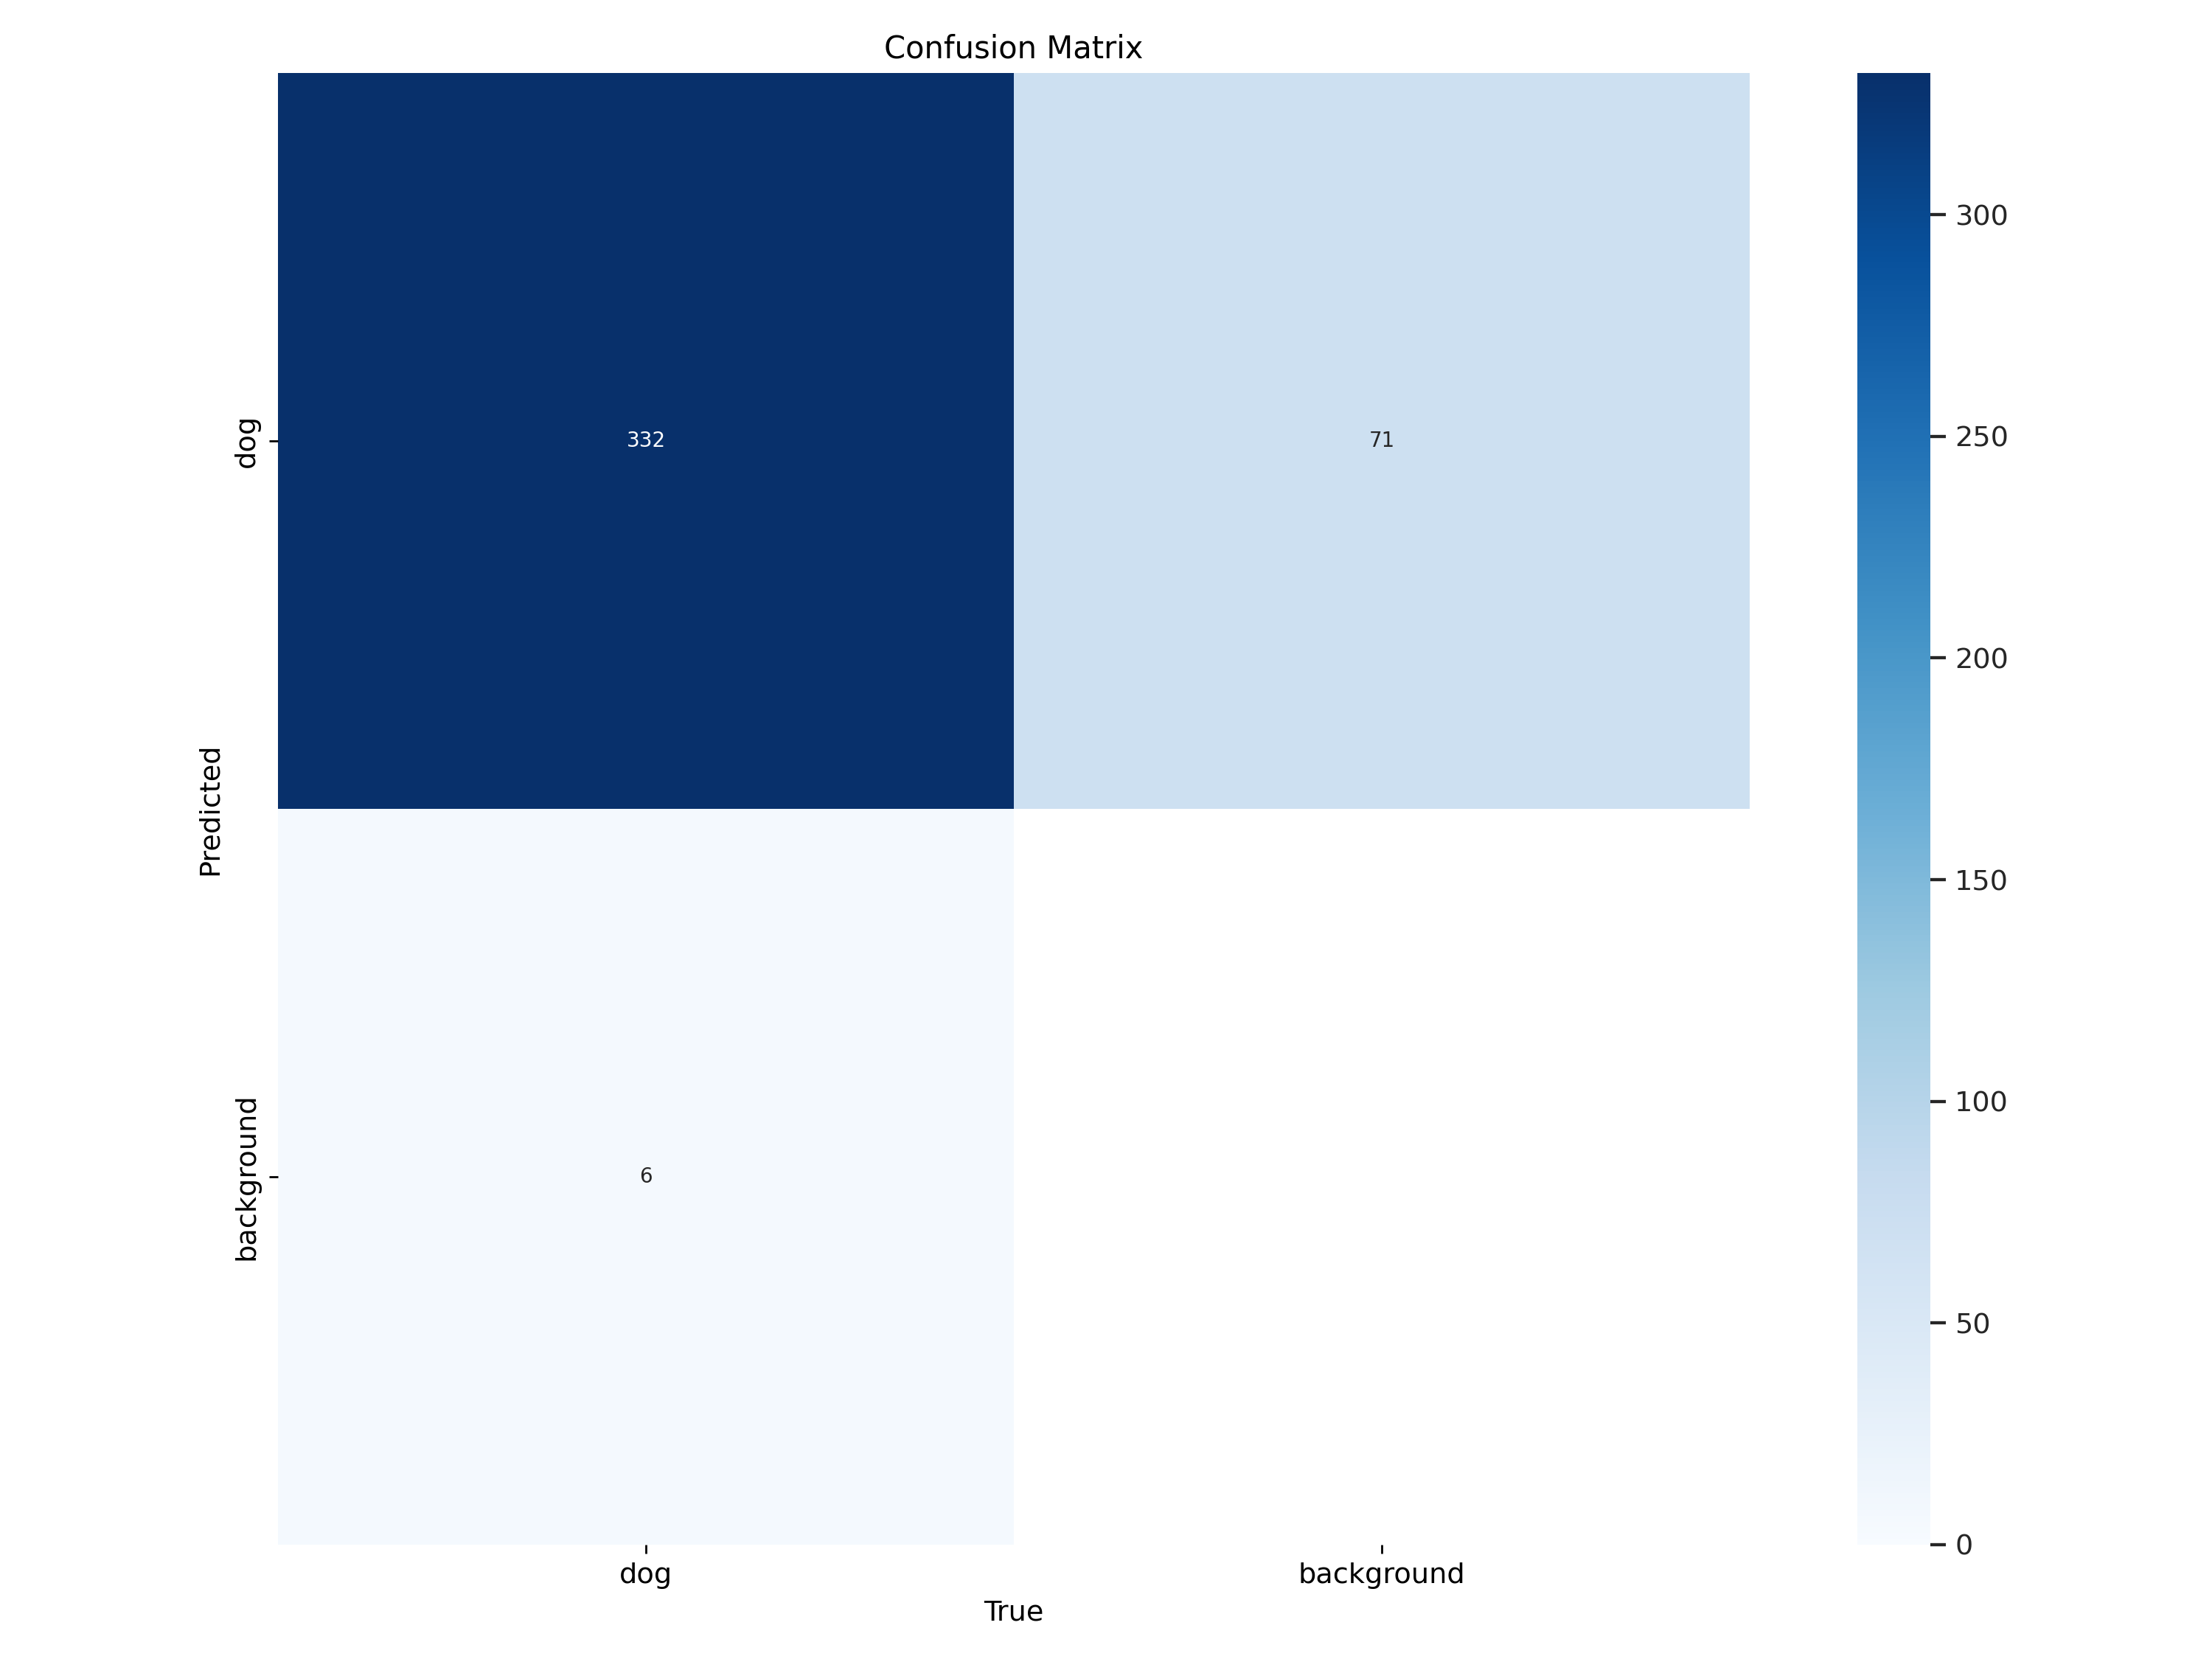

In [12]:
from IPython.display import Image
Image(filename='/content/runs/train2/confusion_matrix.png')


In [15]:
# Прогоняем валидацию
results = model.predict(source='dataset/val/images', save=True, conf=0.25)


image 1/68 /content/dataset/val/images/frame_0012.jpg: 384x640 6 dogs, 64.0ms
image 2/68 /content/dataset/val/images/frame_0015.jpg: 384x640 6 dogs, 8.2ms
image 3/68 /content/dataset/val/images/frame_0026.jpg: 384x640 4 dogs, 8.2ms
image 4/68 /content/dataset/val/images/frame_0030.jpg: 384x640 6 dogs, 8.0ms
image 5/68 /content/dataset/val/images/frame_01_0009.jpg: 384x640 6 dogs, 8.1ms
image 6/68 /content/dataset/val/images/frame_01_0011.jpg: 384x640 5 dogs, 7.9ms
image 7/68 /content/dataset/val/images/frame_01_0012.jpg: 384x640 7 dogs, 7.9ms
image 8/68 /content/dataset/val/images/frame_01_0017.jpg: 384x640 6 dogs, 8.8ms
image 9/68 /content/dataset/val/images/frame_01_0021.jpg: 384x640 5 dogs, 8.1ms
image 10/68 /content/dataset/val/images/frame_01_0024.jpg: 384x640 5 dogs, 8.0ms
image 11/68 /content/dataset/val/images/frame_01_0028.jpg: 384x640 4 dogs, 8.5ms
image 12/68 /content/dataset/val/images/frame_01_0031.jpg: 384x640 3 dogs, 7.7ms
image 13/68 /content/dataset/val/images/frame_0

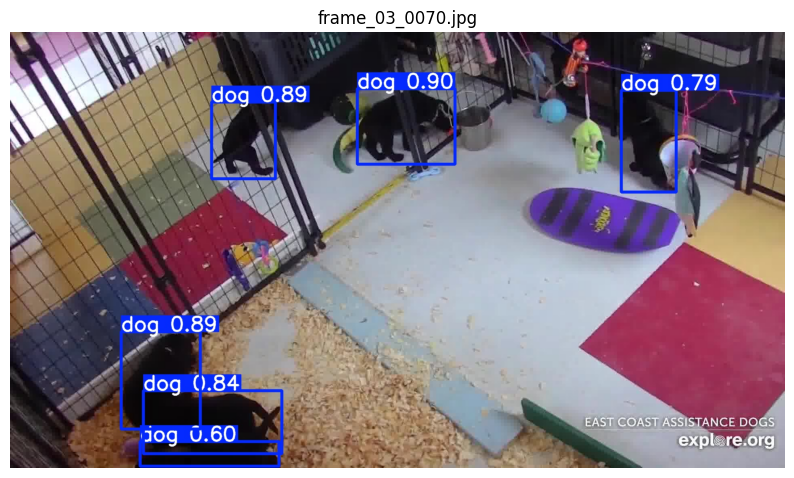

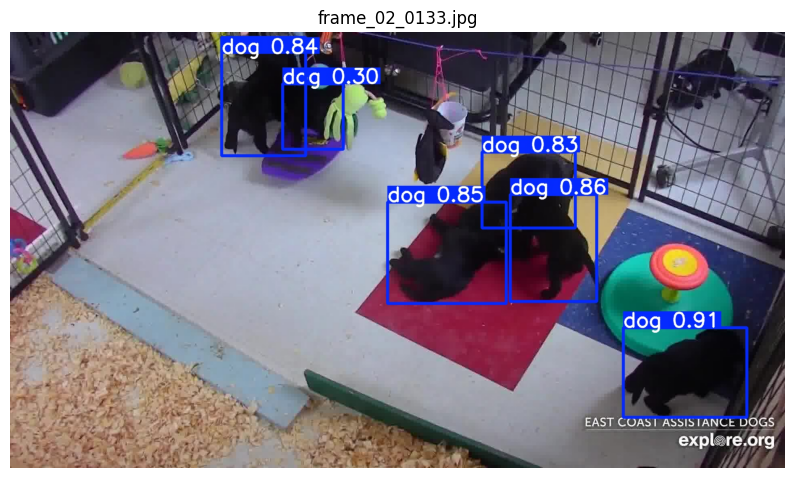

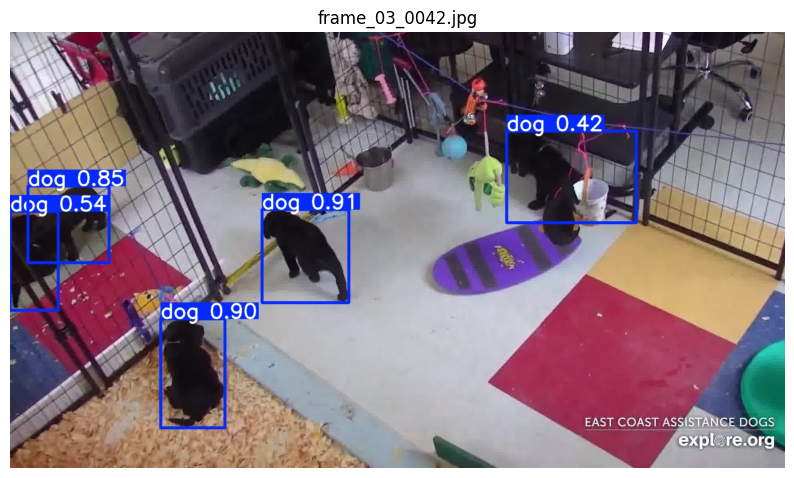

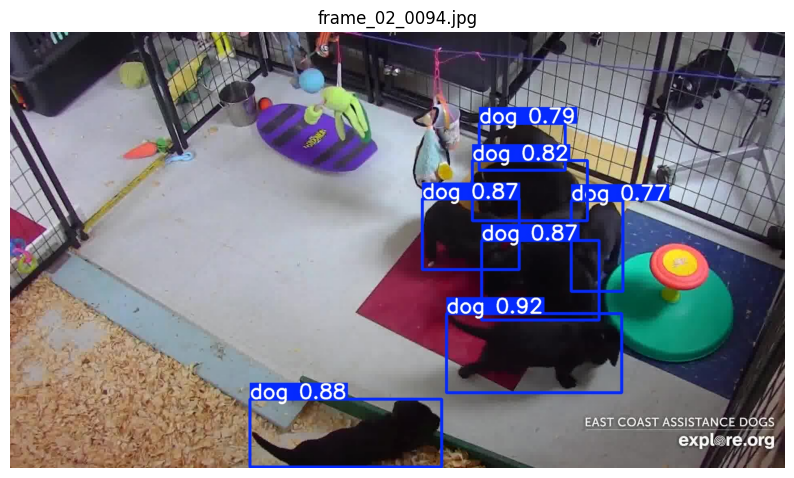

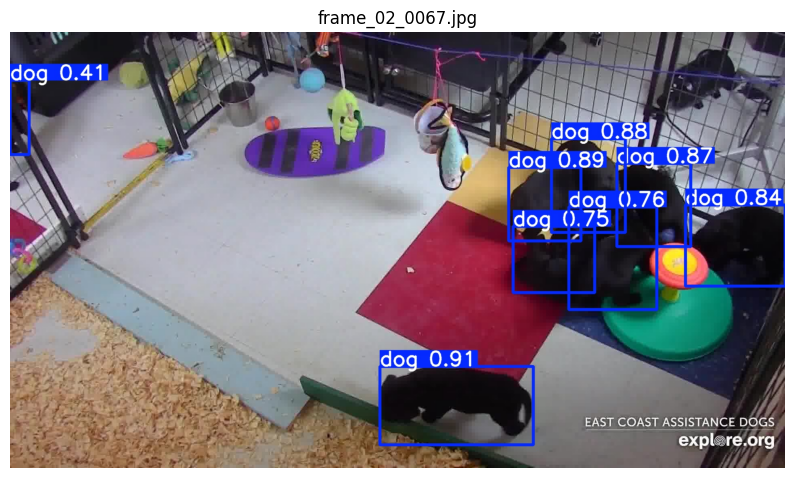

In [18]:
import matplotlib.pyplot as plt
import cv2
import os

def show_predictions(pred_dir, num_images=5):
    image_files = [f for f in os.listdir(pred_dir) if f.endswith(('.jpg', '.png'))]
    for img_file in image_files[:num_images]:
        img_path = os.path.join(pred_dir, img_file)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(img_file)
        plt.show()

# Отображаем первые 5 изображений с предсказаниями
show_predictions('runs/detect/predict')

На отдельных кадрах выглядит очень неплохо, посмотрим инференс на видео